# 📊 Avance 3: Aprendizaje No Supervisado

## 🎯 Contexto

**FinanceGuard** enfrenta una tasa de churn del 20% anual. En este avance, aplicamos técnicas de aprendizaje no supervisado para descubrir patrones ocultos en los datos de clientes y segmentar la base de clientes según su comportamiento.

## 📋 Objetivo

Implementar técnicas de **clustering** y **reducción de dimensionalidad** para:
- Segmentar clientes en grupos con comportamientos similares
- Identificar patrones ocultos en los datos
- Analizar la relación entre segmentos y la tasa de churn
- Generar insights para estrategias de retención

## 🔑 Contenido

1. **K-Means Clustering**: Segmentación básica de clientes
2. **DBSCAN**: Clustering basado en densidad
3. **PCA**: Reducción de dimensionalidad lineal
4. **t-SNE**: Visualización no lineal de datos
5. **Análisis de Churn por Segmento**: Insights de negocio

---

## 1️⃣ Importación de Librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Otras utilidades
from scipy.spatial.distance import cdist

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Carga y Preparación de Datos

Dataset shape: (10000, 14)

📊 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

📈 Distribución de Churn:
Exited
0

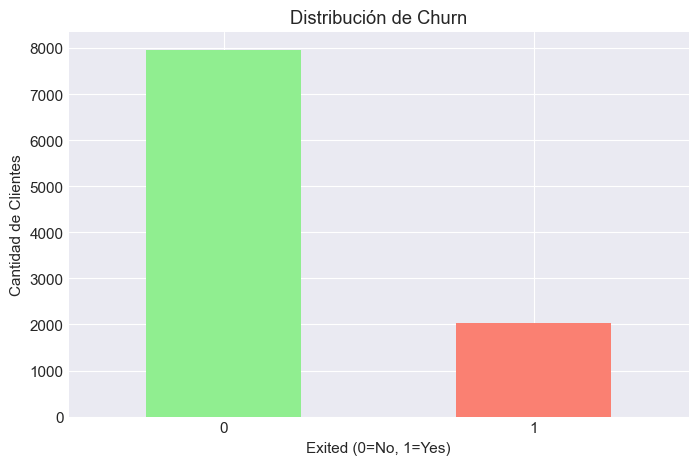

In [2]:
# Cargar datos
df = pd.read_csv('Churn_Modelling.csv')
print(f"Dataset shape: {df.shape}")
print(f"\n📊 Información del dataset:")
print(df.info())

# Análisis de la variable target
print(f"\n📈 Distribución de Churn:")
print(df['Exited'].value_counts())
print(f"\nTasa de Churn: {df['Exited'].mean():.2%}")

# Visualizar distribución
plt.figure(figsize=(8, 5))
df['Exited'].value_counts().plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Distribución de Churn')
plt.xlabel('Exited (0=No, 1=Yes)')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.show()

In [3]:
# Preprocesamiento
# Eliminar columnas no relevantes
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Codificar variables categóricas
le_gender = LabelEncoder()
df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])

le_geo = LabelEncoder()
df_clean['Geography'] = le_geo.fit_transform(df_clean['Geography'])

# Separar features y target
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Escalar datos para clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Crear DataFrame escalado para análisis
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Datos preprocesados y escalados")
print(f"\nShape de X_scaled: {X_scaled.shape}")
print(f"\nPrimeras filas de datos escalados:")
print(X_scaled_df.head())

✅ Datos preprocesados y escalados

Shape de X_scaled: (10000, 10)

Primeras filas de datos escalados:
   CreditScore  Geography    Gender       Age    Tenure   Balance  \
0    -0.326221  -0.901886 -1.095988  0.293517 -1.041760 -1.225848   
1    -0.440036   1.515067 -1.095988  0.198164 -1.387538  0.117350   
2    -1.536794  -0.901886 -1.095988  0.293517  1.032908  1.333053   
3     0.501521  -0.901886 -1.095988  0.007457 -1.387538 -1.225848   
4     2.063884   1.515067 -1.095988  0.388871 -1.041760  0.785728   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  
0      -0.911583   0.646092        0.970243         0.021886  
1      -0.911583  -1.547768        0.970243         0.216534  
2       2.527057   0.646092       -1.030670         0.240687  
3       0.807737  -1.547768       -1.030670        -0.108918  
4      -0.911583   0.646092        0.970243        -0.365276  


## 3️⃣ K-Means Clustering

### 📌 Conceptos Fundamentales

**K-Means** es un algoritmo de clustering que agrupa datos en K clusters basándose en la similitud. 

**Conceptos clave:**
- **Centroides**: Punto central de cada cluster
- **Iteraciones**: El algoritmo actualiza los centroides hasta converger
- **Distancia**: Se usa la distancia euclidiana para asignar puntos a clusters

### 3.1 Método del Codo (Elbow Method)

Ayuda a determinar el número óptimo de clusters K.

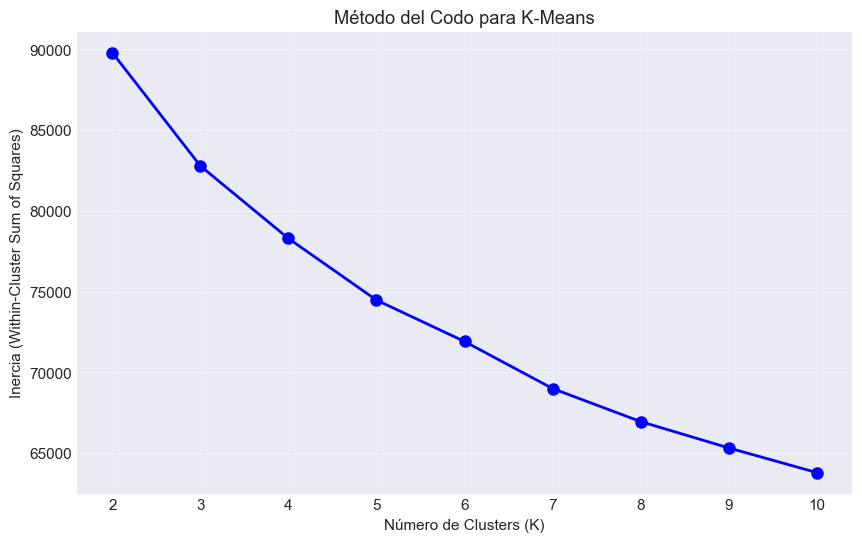

📊 Inercias por K:
K=2: 89805.78
K=3: 82788.88
K=4: 78293.55
K=5: 74476.83
K=6: 71912.92
K=7: 68999.75
K=8: 66951.15
K=9: 65321.74
K=10: 63794.01


In [4]:
# Método del Codo (Elbow Method)
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Visualizar Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Within-Cluster Sum of Squares)')
plt.title('Método del Codo para K-Means')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

print("📊 Inercias por K:")
for k, inertia in zip(K_range, inertias):
    print(f"K={k}: {inertia:.2f}")

### 3.2 Coeficiente de Silueta (Silhouette Score)

El coeficiente de silueta mide qué tan similar es un objeto a su propio cluster comparado con otros clusters. Valores cercanos a 1 indican buena separación.

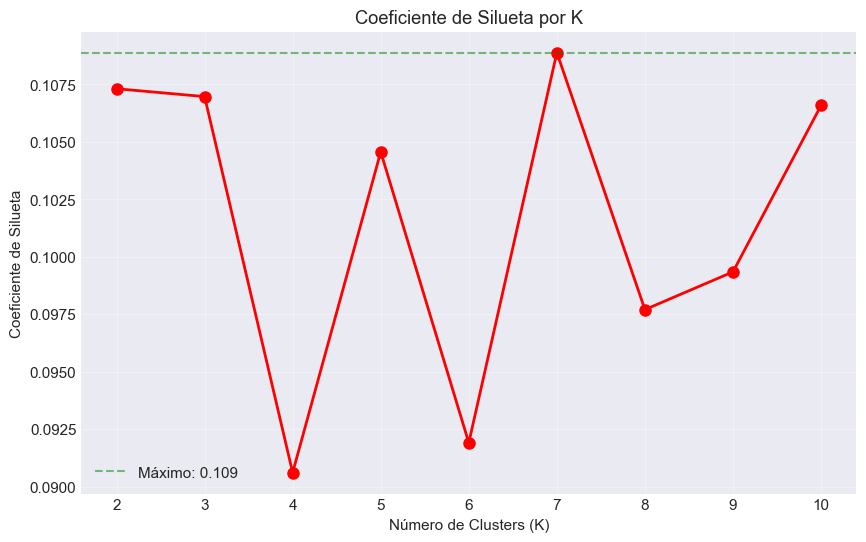

📊 Coeficiente de Silueta por K:
K=2: 0.1073
K=3: 0.1070
K=4: 0.0906
K=5: 0.1046
K=6: 0.0919
K=7: 0.1089
K=8: 0.0977
K=9: 0.0993
K=10: 0.1066

✅ Mejor K según Silhouette Score: 7


In [5]:
# Coeficiente de Silueta
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Visualizar Coeficiente de Silueta
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Coeficiente de Silueta')
plt.title('Coeficiente de Silueta por K')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.axhline(y=max(silhouette_scores), color='g', linestyle='--', alpha=0.5, label=f'Máximo: {max(silhouette_scores):.3f}')
plt.legend()
plt.show()

print("📊 Coeficiente de Silueta por K:")
for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: {score:.4f}")
    
# Identificar el mejor K
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n✅ Mejor K según Silhouette Score: {best_k}")

### 3.3 Implementación K-Means con K Óptimo

Aplicamos K-Means con K=4 (basándonos en los análisis anteriores).

📊 Métricas K-Means (K=4):
Coeficiente de Silueta: 0.0906
Davies-Bouldin Score: 2.4386 (menor es mejor)

📈 Distribución de clusters:
Cluster_KMeans
0    2899
1    2217
2    2195
3    2689
Name: count, dtype: int64


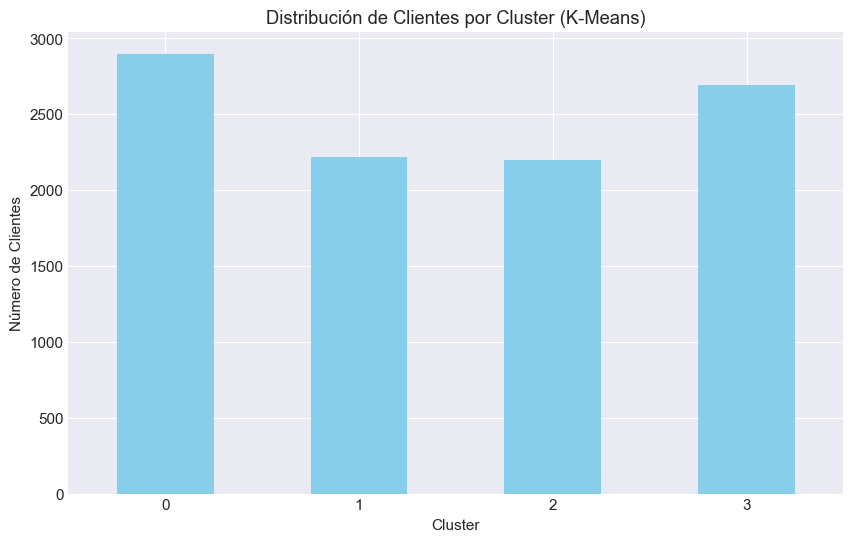

In [6]:
# K-Means con K=4
k_optimal = 4
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters_kmeans = kmeans_final.fit_predict(X_scaled)

# Agregar clusters al DataFrame original
df_clean['Cluster_KMeans'] = clusters_kmeans

# Métricas del clustering
silhouette_avg = silhouette_score(X_scaled, clusters_kmeans)
db_score = davies_bouldin_score(X_scaled, clusters_kmeans)

print(f"📊 Métricas K-Means (K={k_optimal}):")
print(f"Coeficiente de Silueta: {silhouette_avg:.4f}")
print(f"Davies-Bouldin Score: {db_score:.4f} (menor es mejor)")

# Distribución de clusters
print(f"\n📈 Distribución de clusters:")
print(df_clean['Cluster_KMeans'].value_counts().sort_index())

# Visualizar distribución
plt.figure(figsize=(10, 6))
df_clean['Cluster_KMeans'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribución de Clientes por Cluster (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=0)
plt.show()

### 3.4 Análisis de Centroides

Los centroides representan el "centro" de cada cluster y nos ayudan a entender las características de cada segmento.

📊 Centroides de cada Cluster (valores escalados):
   CreditScore  Geography  Gender    Age  Tenure  Balance  NumOfProducts  \
0        0.009      0.014  -0.006  0.014  -0.035    0.036         -0.055   
1       -0.009      0.025  -1.096  0.070  -0.026    0.424         -0.440   
2        0.020     -0.087  -0.003 -0.085   0.047   -1.059          1.066   
3       -0.019      0.036   0.912 -0.004   0.021    0.476         -0.449   

   HasCrCard  IsActiveMember  EstimatedSalary  
0     -1.548           0.019            0.015  
1      0.646          -0.054            0.008  
2      0.600           0.020           -0.015  
3      0.646           0.007           -0.010  


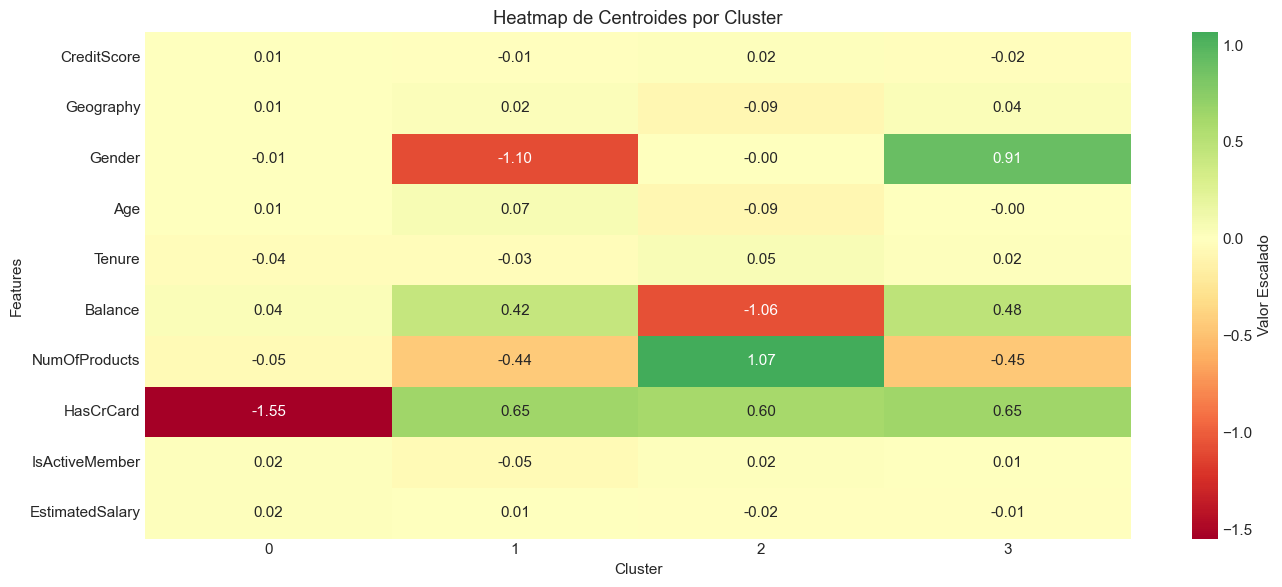


📊 Características promedio por cluster (datos originales):
                CreditScore  Geography  Gender    Age  Tenure    Balance  \
Cluster_KMeans                                                             
0                    651.39       0.76    0.54  39.07    4.91   78715.94   
1                    649.65       0.77    0.00  39.65    4.94  102955.44   
2                    652.49       0.67    0.54  38.03    5.15   10409.24   
3                    648.73       0.78    1.00  38.88    5.07  106195.95   

                NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  
Cluster_KMeans                                                             
0                        1.50       0.00            0.52        100958.39  
1                        1.27       1.00            0.49        100533.15  
2                        2.15       0.98            0.53         99222.12  
3                        1.27       1.00            0.52         99497.77  


In [7]:
# Análisis de centroides
centroids = kmeans_final.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=X.columns)

print("📊 Centroides de cada Cluster (valores escalados):")
print(centroids_df.round(3))

# Visualizar centroides en heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(centroids_df.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Valor Escalado'})
plt.title('Heatmap de Centroides por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Características promedio por cluster (datos originales)
print("\n📊 Características promedio por cluster (datos originales):")
cluster_profiles = df_clean.groupby('Cluster_KMeans')[X.columns].mean()
print(cluster_profiles.round(2))

## 4️⃣ DBSCAN (Density-Based Clustering)

### 📌 Conceptos Fundamentales

**DBSCAN** es un algoritmo de clustering basado en densidad que puede encontrar clusters de forma arbitraria y detectar outliers.

**Conceptos clave:**
- **Core Points**: Puntos con al menos `min_samples` vecinos dentro del radio `eps`
- **Border Points**: Puntos en el borde de un cluster
- **Noise**: Puntos que no pertenecen a ningún cluster (outliers)
- **eps (epsilon)**: Radio de vecindad para buscar puntos cercanos
- **min_samples**: Número mínimo de puntos para formar un cluster

**Ventajas:**
- No requiere especificar el número de clusters K
- Puede detectar outliers
- Encuentra clusters de forma irregular

📊 Resultados DBSCAN:
Número de clusters encontrados: 0
Número de outliers (noise): 10000
Porcentaje de outliers: 100.00%

📈 Distribución de clusters:
Cluster_DBSCAN
-1    10000
Name: count, dtype: int64


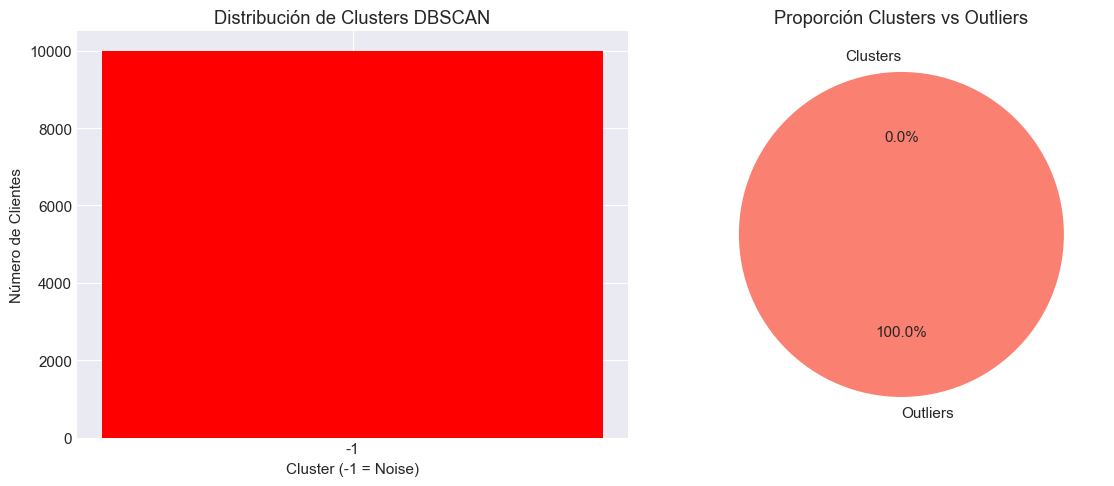

In [8]:
# DBSCAN clustering
# Parámetros: eps=0.5, min_samples=50
dbscan = DBSCAN(eps=0.5, min_samples=50)
clusters_dbscan = dbscan.fit_predict(X_scaled)

# Agregar clusters al DataFrame
df_clean['Cluster_DBSCAN'] = clusters_dbscan

# Análisis de clusters
n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)

print(f"📊 Resultados DBSCAN:")
print(f"Número de clusters encontrados: {n_clusters}")
print(f"Número de outliers (noise): {n_noise}")
print(f"Porcentaje de outliers: {n_noise/len(clusters_dbscan)*100:.2f}%")

# Distribución de clusters
print(f"\n📈 Distribución de clusters:")
print(df_clean['Cluster_DBSCAN'].value_counts().sort_index())

# Visualizar distribución
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cluster_counts = df_clean['Cluster_DBSCAN'].value_counts().sort_index()
colors = ['red' if x == -1 else 'skyblue' for x in cluster_counts.index]
plt.bar(range(len(cluster_counts)), cluster_counts.values, color=colors)
plt.xlabel('Cluster (-1 = Noise)')
plt.ylabel('Número de Clientes')
plt.title('Distribución de Clusters DBSCAN')
plt.xticks(range(len(cluster_counts)), cluster_counts.index)

plt.subplot(1, 2, 2)
labels = ['Clusters', 'Outliers']
sizes = [len(clusters_dbscan) - n_noise, n_noise]
colors_pie = ['skyblue', 'salmon']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_pie, startangle=90)
plt.title('Proporción Clusters vs Outliers')

plt.tight_layout()
plt.show()

### 4.1 Comparación K-Means vs DBSCAN

In [9]:
# Comparación K-Means vs DBSCAN
print("📊 Comparación de Algoritmos:\n")

print("K-Means:")
print(f"  - Clusters definidos: {k_optimal}")
print(f"  - Asigna todos los puntos a un cluster")
print(f"  - Silhouette Score: {silhouette_avg:.4f}")

print(f"\nDBSCAN:")
print(f"  - Clusters encontrados: {n_clusters}")
print(f"  - Outliers detectados: {n_noise} ({n_noise/len(clusters_dbscan)*100:.2f}%)")
print(f"  - Encuentra clusters de forma irregular")

print("\n🔑 Cuándo usar cada uno:")
print("  K-Means: Cuando se conoce aproximadamente el número de clusters y los clusters son esféricos")
print("  DBSCAN: Cuando se busca detectar outliers y los clusters tienen formas irregulares")

📊 Comparación de Algoritmos:

K-Means:
  - Clusters definidos: 4
  - Asigna todos los puntos a un cluster
  - Silhouette Score: 0.0906

DBSCAN:
  - Clusters encontrados: 0
  - Outliers detectados: 10000 (100.00%)
  - Encuentra clusters de forma irregular

🔑 Cuándo usar cada uno:
  K-Means: Cuando se conoce aproximadamente el número de clusters y los clusters son esféricos
  DBSCAN: Cuando se busca detectar outliers y los clusters tienen formas irregulares


## 5️⃣ PCA (Principal Component Analysis)

### 📌 Conceptos Fundamentales

**PCA** es una técnica de reducción de dimensionalidad lineal que transforma los datos a un nuevo sistema de coordenadas donde las dimensiones (componentes principales) capturan la máxima varianza.

**Conceptos clave:**
- **Componentes Principales**: Nuevas variables que son combinaciones lineales de las originales
- **Varianza Explicada**: Porcentaje de información que captura cada componente
- **Reducción de Dimensionalidad**: Pasar de muchas variables a pocas manteniendo la información

**Ventajas:**
- Reduce la dimensionalidad preservando la varianza
- Ayuda a visualizar datos de alta dimensión
- Elimina correlaciones entre variables

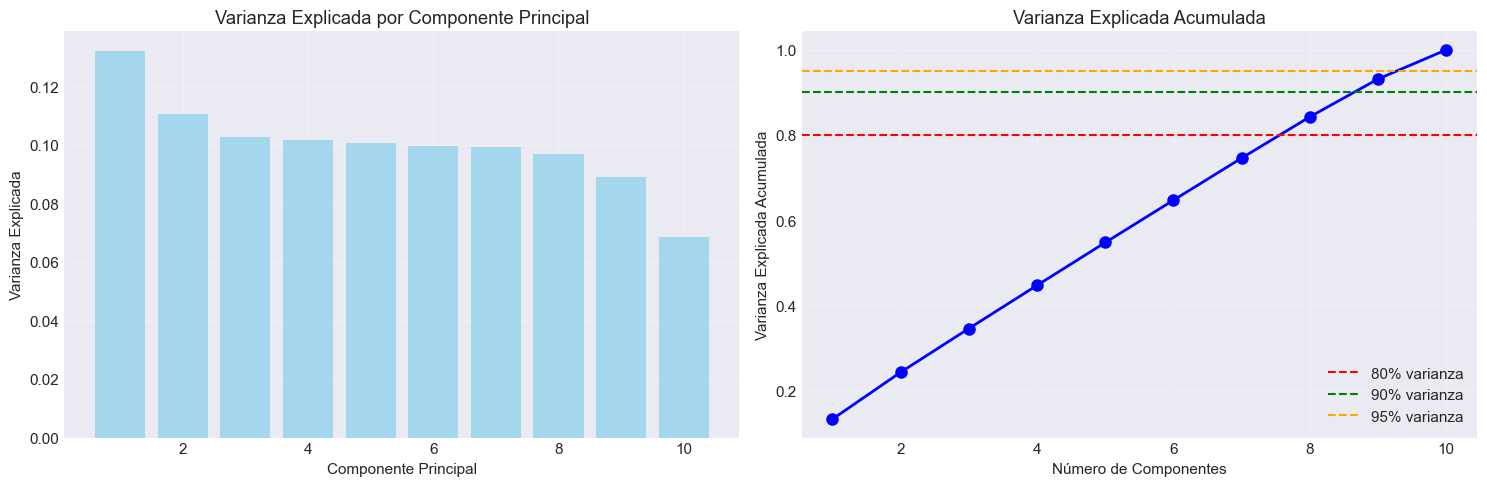

Componentes para 80% varianza: 8
Componentes para 90% varianza: 9
Componentes para 95% varianza: 10

Varianza explicada por las primeras 3 componentes: 34.50%


In [10]:
# PCA - Varianza explicada
pca_full = PCA()
pca_full.fit(X_scaled)

# Varianza explicada acumulada
variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

# Visualizar varianza explicada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Varianza por componente
ax1.bar(range(1, len(variance_ratio)+1), variance_ratio, alpha=0.7, color='skyblue')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada')
ax1.set_title('Varianza Explicada por Componente Principal')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Varianza acumulada
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-', linewidth=2, markersize=8)
ax2.axhline(y=0.80, color='r', linestyle='--', label='80% varianza')
ax2.axhline(y=0.90, color='g', linestyle='--', label='90% varianza')
ax2.axhline(y=0.95, color='orange', linestyle='--', label='95% varianza')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Explicada Acumulada')
ax2.set_title('Varianza Explicada Acumulada')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Número de componentes para diferentes umbrales
for threshold in [0.80, 0.90, 0.95]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Componentes para {threshold*100:.0f}% varianza: {n_components}")

print(f"\nVarianza explicada por las primeras 3 componentes: {cumulative_variance[2]:.2%}")

### 5.1 Visualización 2D con PCA

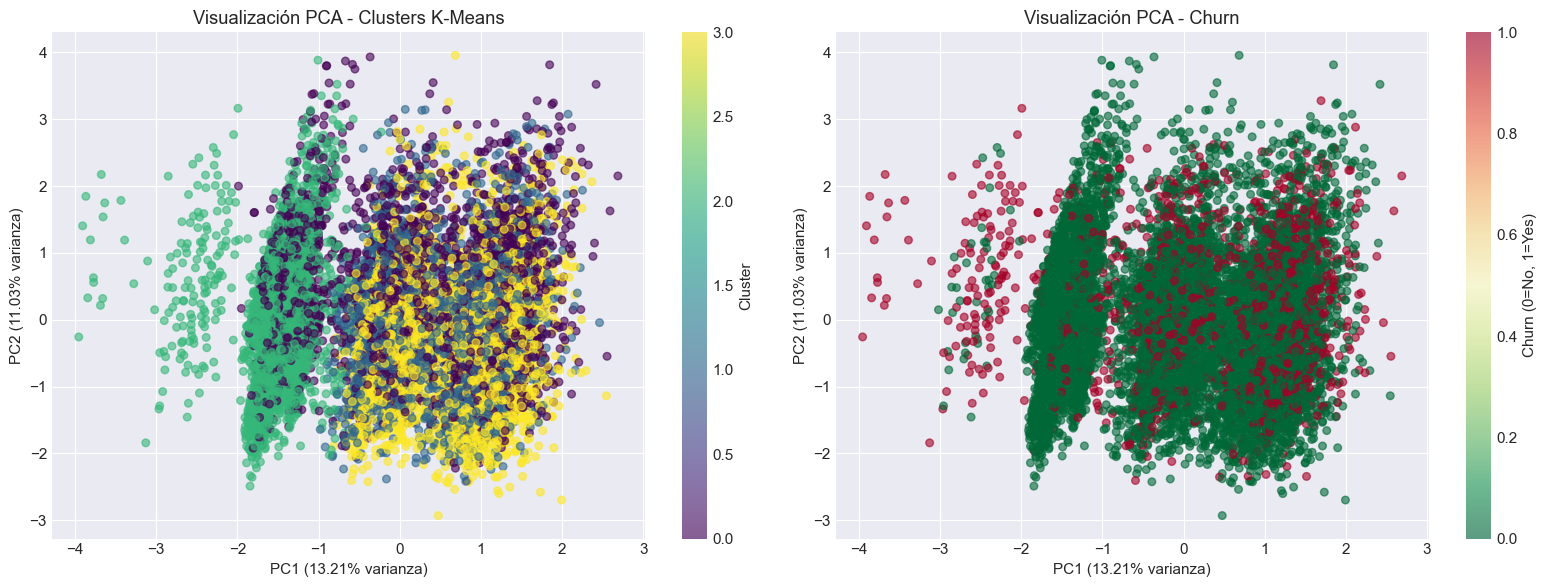

Varianza explicada por PC1 y PC2: 24.24%


In [11]:
# PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Crear DataFrame con resultados
pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Cluster_KMeans'] = clusters_kmeans
pca_df['Churn'] = y.values

# Visualización de clusters K-Means en espacio PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Clusters K-Means
scatter1 = ax1.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster_KMeans'], 
                       cmap='viridis', alpha=0.6, s=30)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} varianza)')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} varianza)')
ax1.set_title('Visualización PCA - Clusters K-Means')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Gráfico 2: Churn
scatter2 = ax2.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Churn'], 
                       cmap='RdYlGn_r', alpha=0.6, s=30)
ax2.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} varianza)')
ax2.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} varianza)')
ax2.set_title('Visualización PCA - Churn')
plt.colorbar(scatter2, ax=ax2, label='Churn (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

print(f"Varianza explicada por PC1 y PC2: {sum(pca_2d.explained_variance_ratio_):.2%}")

### 5.2 Visualización 3D con PCA

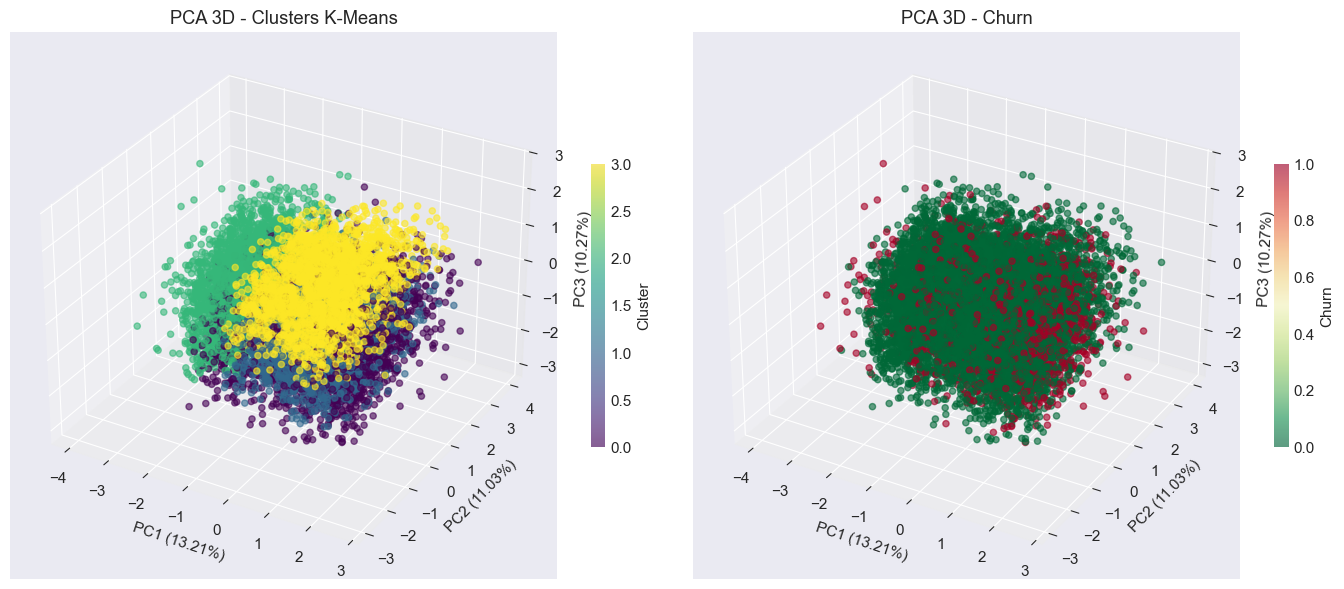

Varianza explicada por 3 componentes: 34.50%


In [12]:
# PCA 3D
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Crear figura 3D
fig = plt.figure(figsize=(14, 6))

# Subplot 1: Clusters
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                       c=clusters_kmeans, cmap='viridis', alpha=0.6, s=20)
ax1.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})')
ax1.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})')
ax1.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})')
ax1.set_title('PCA 3D - Clusters K-Means')
plt.colorbar(scatter1, ax=ax1, label='Cluster', shrink=0.5)

# Subplot 2: Churn
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                       c=y, cmap='RdYlGn_r', alpha=0.6, s=20)
ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})')
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})')
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})')
ax2.set_title('PCA 3D - Churn')
plt.colorbar(scatter2, ax=ax2, label='Churn', shrink=0.5)

plt.tight_layout()
plt.show()

print(f"Varianza explicada por 3 componentes: {sum(pca_3d.explained_variance_ratio_):.2%}")

## 6️⃣ t-SNE (t-Distributed Stochastic Neighbor Embedding)

### 📌 Conceptos Fundamentales

**t-SNE** es una técnica de reducción de dimensionalidad no lineal especialmente útil para visualización de datos de alta dimensión.

**Conceptos clave:**
- **No lineal**: Captura relaciones complejas que PCA no puede
- **Perplexity**: Parámetro que balancea aspectos locales y globales (típicamente 5-50)
- **Preserva vecindades**: Mantiene puntos similares cerca en el espacio reducido

**Diferencias con PCA:**
- PCA es lineal, t-SNE es no lineal
- PCA preserva varianza global, t-SNE preserva estructura local
- t-SNE es mejor para visualización, PCA para reducción de dimensionalidad general

**Limitaciones:**
- Computacionalmente costoso
- No determinístico (resultados varían entre ejecuciones)
- No se debe interpretar distancias absolutas

🚀 Ejecutando t-SNE (esto puede tomar algunos minutos)...
💡 Usando muestra de 2000 puntos para optimizar tiempo de ejecución

Procesando perplexity=5...
Procesando perplexity=30...
Procesando perplexity=30...
Procesando perplexity=50...
Procesando perplexity=50...
Procesando perplexity=100...
Procesando perplexity=100...


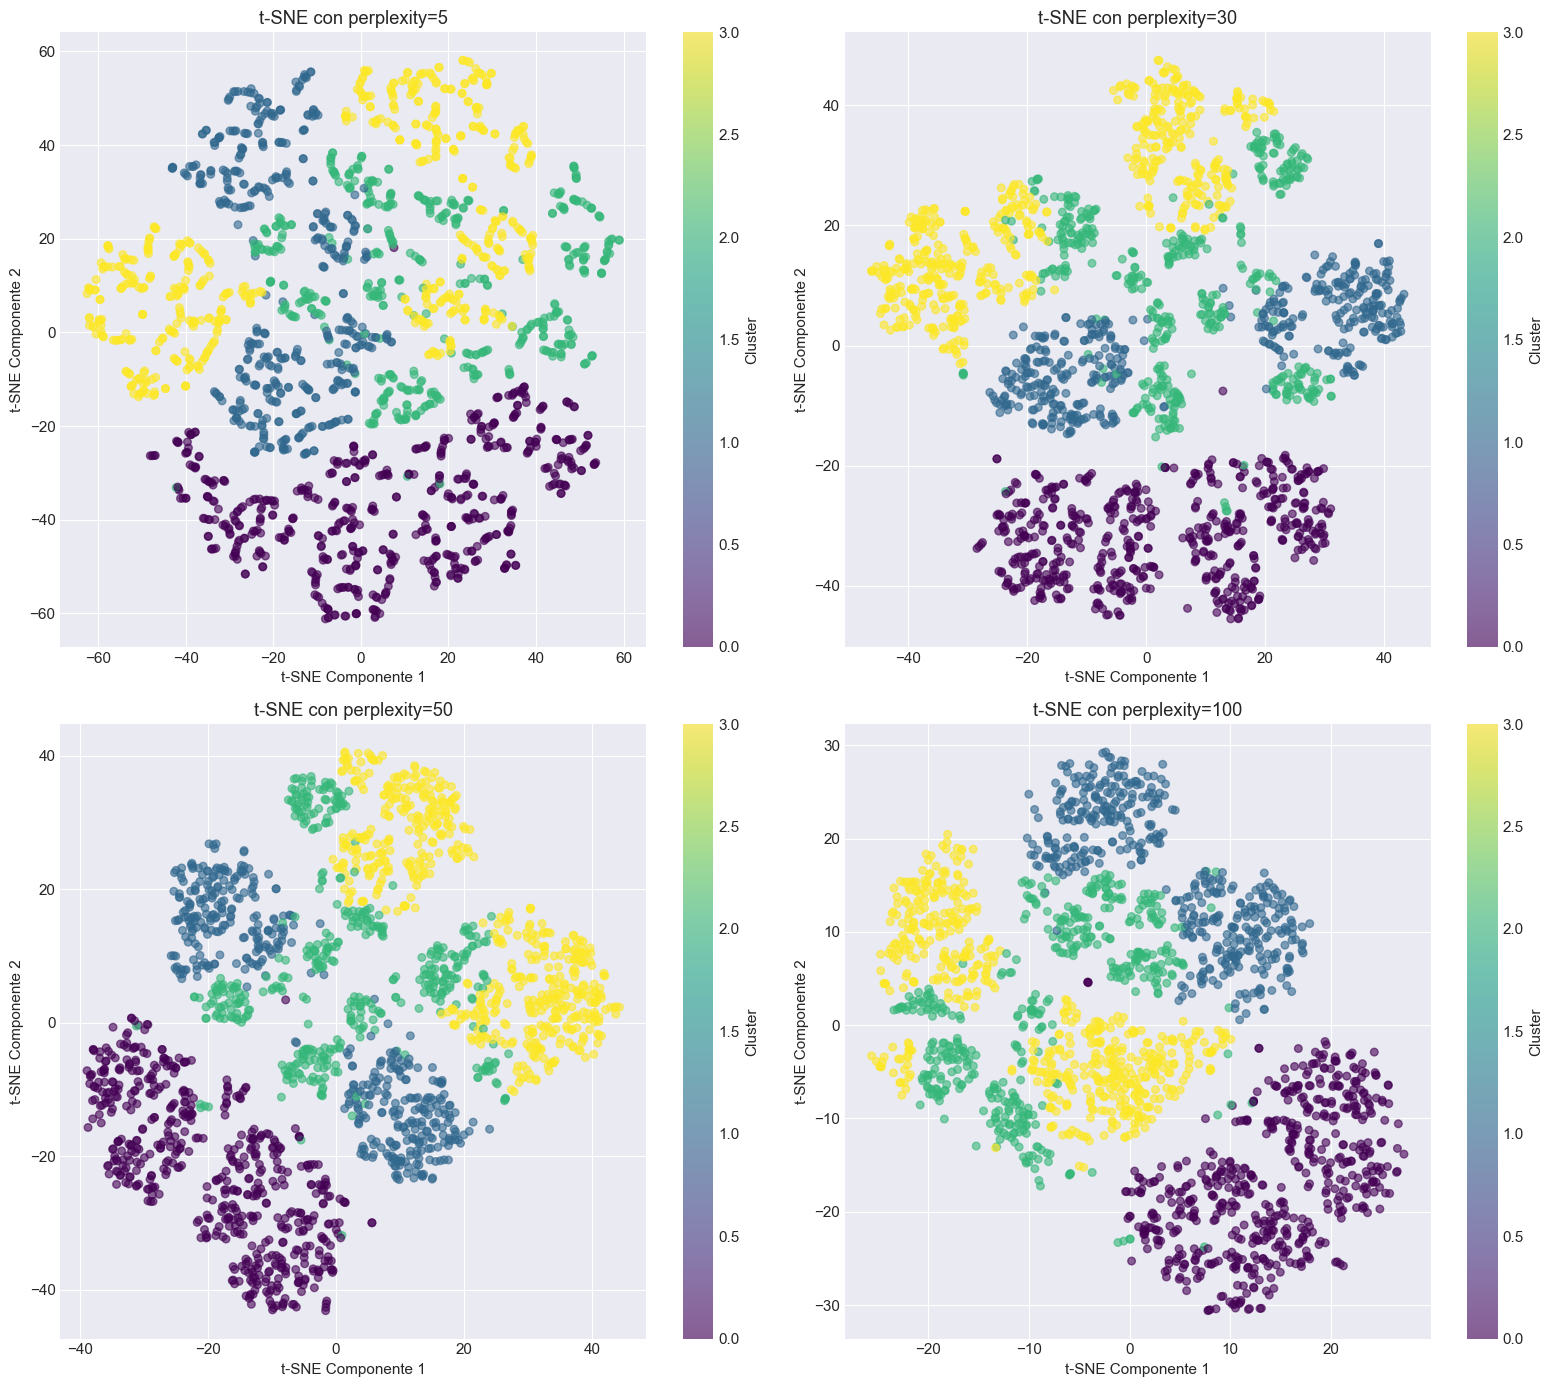


✅ t-SNE completado


In [16]:
# t-SNE con diferentes valores de perplexity
# Nota: Usamos una muestra para acelerar el proceso
print("🚀 Ejecutando t-SNE (esto puede tomar algunos minutos)...")
print("💡 Usando muestra de 2000 puntos para optimizar tiempo de ejecución\n")

# Tomar muestra estratificada
np.random.seed(42)
sample_size = 2000
sample_indices = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_indices]
clusters_sample = clusters_kmeans[sample_indices]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
perplexity_values = [5, 30, 50, 100]

for idx, perplexity in enumerate(perplexity_values):
    print(f"Procesando perplexity={perplexity}...")
    ax = axes[idx // 2, idx % 2]
    
    # t-SNE con parámetros optimizados
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, 
                max_iter=500, learning_rate=200, init='pca')
    X_tsne = tsne.fit_transform(X_sample)
    
    # Visualizar
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters_sample, 
                        cmap='viridis', alpha=0.6, s=30)
    ax.set_title(f't-SNE con perplexity={perplexity}')
    ax.set_xlabel('t-SNE Componente 1')
    ax.set_ylabel('t-SNE Componente 2')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.show()

print("\n✅ t-SNE completado")

🚀 Ejecutando t-SNE final con perplexity=30...


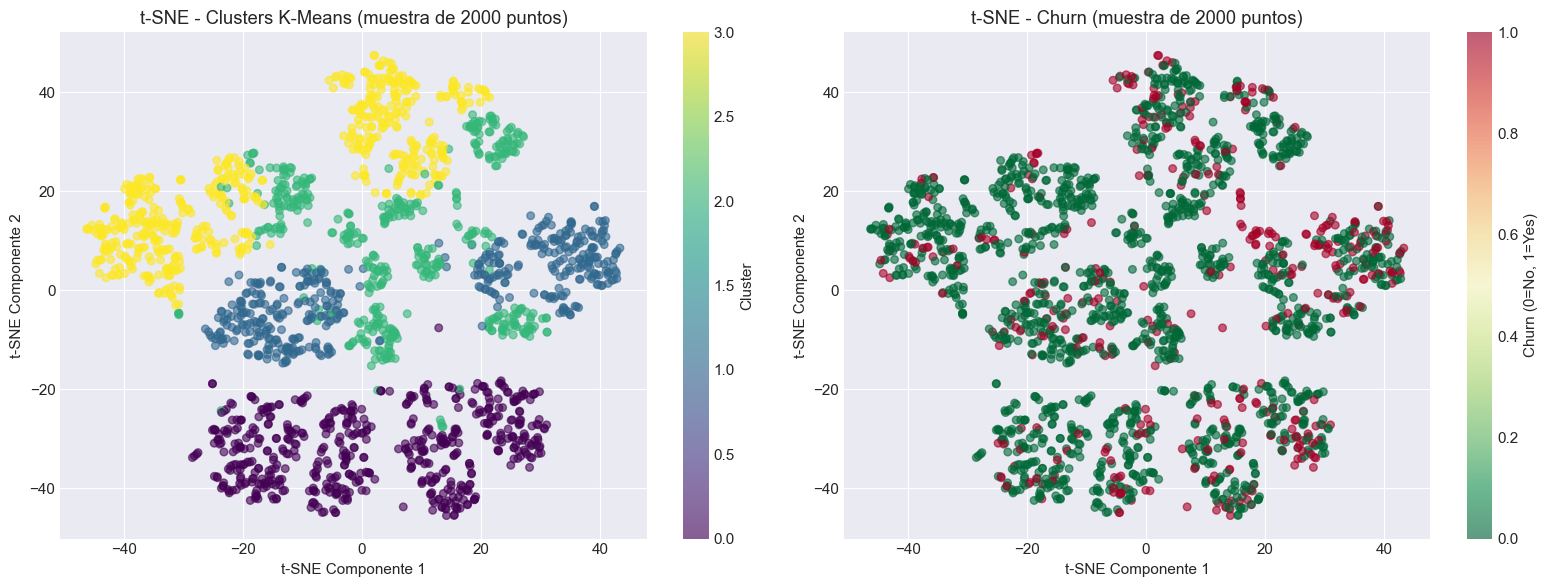

✅ t-SNE final completado


In [17]:
# t-SNE final con perplexity óptimo
print("🚀 Ejecutando t-SNE final con perplexity=30...")

tsne_final = TSNE(n_components=2, perplexity=30, random_state=42, 
                  max_iter=500, learning_rate=200, init='pca')
X_tsne_final = tsne_final.fit_transform(X_sample)

# Visualización comparativa: Clusters vs Churn
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Clusters
scatter1 = ax1.scatter(X_tsne_final[:, 0], X_tsne_final[:, 1], c=clusters_sample, 
                       cmap='viridis', alpha=0.6, s=30)
ax1.set_xlabel('t-SNE Componente 1')
ax1.set_ylabel('t-SNE Componente 2')
ax1.set_title('t-SNE - Clusters K-Means (muestra de 2000 puntos)')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Gráfico 2: Churn
y_sample = y.values[sample_indices]
scatter2 = ax2.scatter(X_tsne_final[:, 0], X_tsne_final[:, 1], c=y_sample, 
                       cmap='RdYlGn_r', alpha=0.6, s=30)
ax2.set_xlabel('t-SNE Componente 1')
ax2.set_ylabel('t-SNE Componente 2')
ax2.set_title('t-SNE - Churn (muestra de 2000 puntos)')
plt.colorbar(scatter2, ax=ax2, label='Churn (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

print("✅ t-SNE final completado")

## 7️⃣ Análisis de Churn por Segmento

### Análisis de Perfiles de Clientes por Cluster

Ahora analizamos las características de cada cluster y su relación con el churn.

📊 Tasa de Churn por Cluster:
                Total_Churn  Total_Clientes  Tasa_Churn  Tasa_Churn_Pct
Cluster_KMeans                                                         
0                       578            2899        0.20           19.94
1                       644            2217        0.29           29.05
2                       291            2195        0.13           13.26
3                       524            2689        0.19           19.49


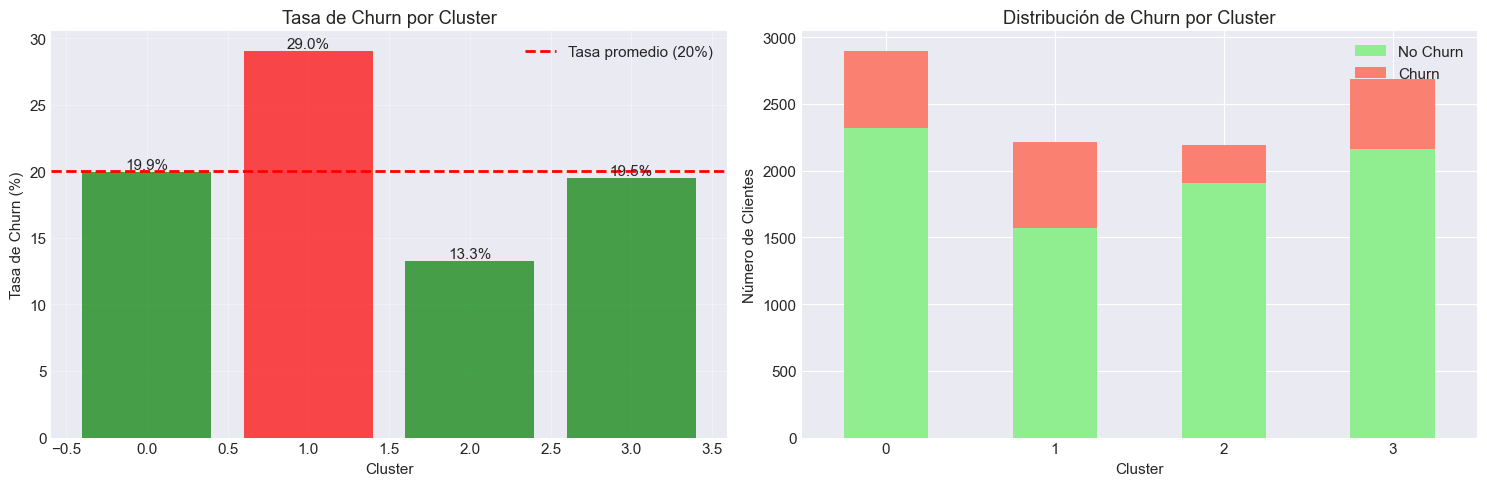


⚠️ Clusters de alto riesgo (>20% churn): [1]


In [18]:
# Análisis de tasa de churn por cluster
churn_by_cluster = df_clean.groupby('Cluster_KMeans')['Exited'].agg(['sum', 'count', 'mean'])
churn_by_cluster.columns = ['Total_Churn', 'Total_Clientes', 'Tasa_Churn']
churn_by_cluster['Tasa_Churn_Pct'] = churn_by_cluster['Tasa_Churn'] * 100

print("📊 Tasa de Churn por Cluster:")
print(churn_by_cluster.round(2))

# Visualizar tasa de churn por cluster
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Tasa de churn
colors = ['green' if x < 20 else 'orange' if x < 25 else 'red' 
          for x in churn_by_cluster['Tasa_Churn_Pct']]
bars = ax1.bar(churn_by_cluster.index, churn_by_cluster['Tasa_Churn_Pct'], color=colors, alpha=0.7)
ax1.axhline(y=20, color='red', linestyle='--', label='Tasa promedio (20%)', linewidth=2)
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Tasa de Churn (%)')
ax1.set_title('Tasa de Churn por Cluster')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Agregar valores sobre las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom')

# Gráfico 2: Distribución de churn
churn_dist = df_clean.groupby(['Cluster_KMeans', 'Exited']).size().unstack()
churn_dist.plot(kind='bar', stacked=True, ax=ax2, color=['lightgreen', 'salmon'])
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Número de Clientes')
ax2.set_title('Distribución de Churn por Cluster')
ax2.legend(['No Churn', 'Churn'], loc='upper right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Identificar clusters de alto riesgo
high_risk_clusters = churn_by_cluster[churn_by_cluster['Tasa_Churn_Pct'] > 20].index.tolist()
print(f"\n⚠️ Clusters de alto riesgo (>20% churn): {high_risk_clusters}")

### 7.1 Perfiles Demográficos por Cluster

📊 Perfil Demográfico por Cluster:
         CreditScore    Age  Tenure    Balance  NumOfProducts  HasCrCard  \
Cluster                                                                    
0             651.39  39.07    4.91   78715.94           1.50       0.00   
1             649.65  39.65    4.94  102955.44           1.27       1.00   
2             652.49  38.03    5.15   10409.24           2.15       0.98   
3             648.73  38.88    5.07  106195.95           1.27       1.00   

         IsActiveMember  EstimatedSalary  Exited  
Cluster                                           
0                  0.52        100958.39    0.20  
1                  0.49        100533.15    0.29  
2                  0.53         99222.12    0.13  
3                  0.52         99497.77    0.19  


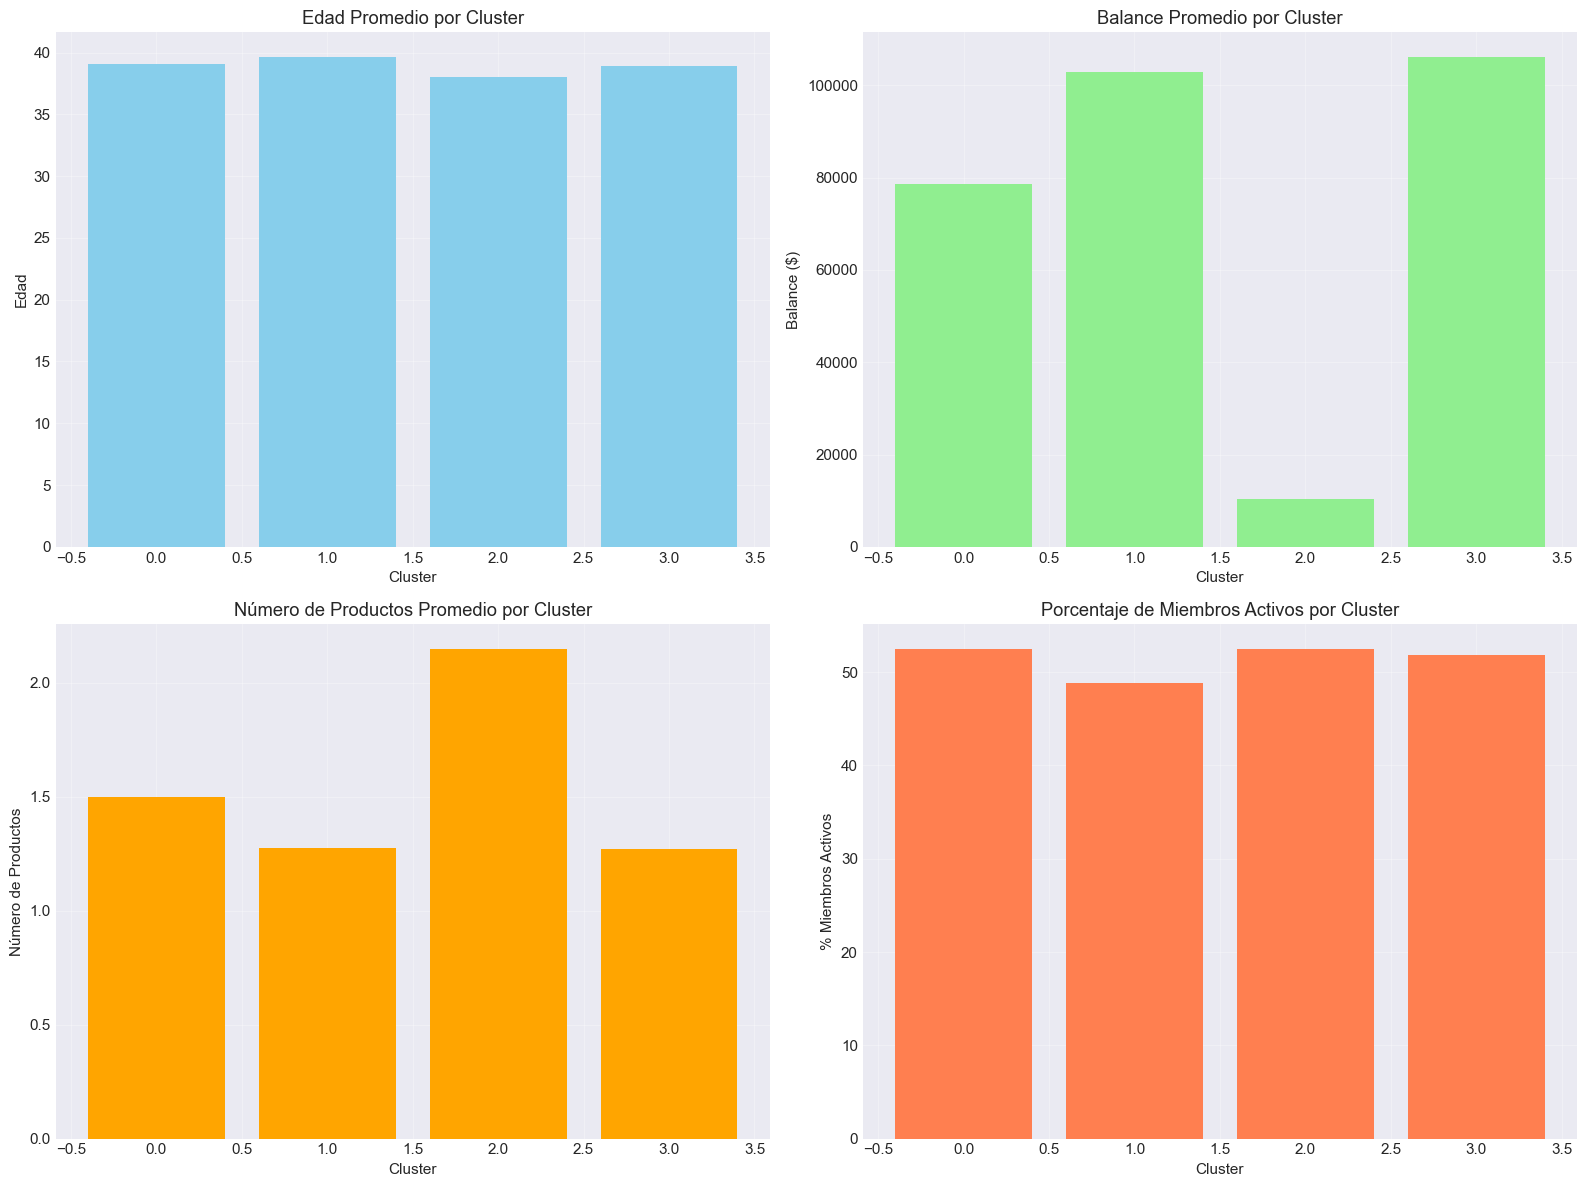

In [19]:
# Perfiles por cluster
# Reconstruir datos originales
df_analysis = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1).copy()
df_analysis['Cluster'] = clusters_kmeans

# Análisis demográfico
demographic_profile = df_analysis.groupby('Cluster').agg({
    'CreditScore': 'mean',
    'Age': 'mean',
    'Tenure': 'mean',
    'Balance': 'mean',
    'NumOfProducts': 'mean',
    'HasCrCard': 'mean',
    'IsActiveMember': 'mean',
    'EstimatedSalary': 'mean',
    'Exited': 'mean'
})

print("📊 Perfil Demográfico por Cluster:")
print(demographic_profile.round(2))

# Visualizar perfiles
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Edad
axes[0, 0].bar(demographic_profile.index, demographic_profile['Age'], color='skyblue')
axes[0, 0].set_title('Edad Promedio por Cluster')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Edad')
axes[0, 0].grid(True, alpha=0.3)

# Balance
axes[0, 1].bar(demographic_profile.index, demographic_profile['Balance'], color='lightgreen')
axes[0, 1].set_title('Balance Promedio por Cluster')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Balance ($)')
axes[0, 1].grid(True, alpha=0.3)

# Número de productos
axes[1, 0].bar(demographic_profile.index, demographic_profile['NumOfProducts'], color='orange')
axes[1, 0].set_title('Número de Productos Promedio por Cluster')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Número de Productos')
axes[1, 0].grid(True, alpha=0.3)

# Miembro activo
axes[1, 1].bar(demographic_profile.index, demographic_profile['IsActiveMember']*100, color='coral')
axes[1, 1].set_title('Porcentaje de Miembros Activos por Cluster')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('% Miembros Activos')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Interpretación y Nomenclatura de Clusters

In [20]:
# Interpretación de clusters basada en características
print("🔍 INTERPRETACIÓN DE CLUSTERS:\n")

for cluster in sorted(df_analysis['Cluster'].unique()):
    cluster_data = df_analysis[df_analysis['Cluster'] == cluster]
    
    print(f"{'='*60}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*60}")
    
    print(f"📊 Tamaño: {len(cluster_data)} clientes ({len(cluster_data)/len(df_analysis)*100:.1f}%)")
    print(f"⚠️ Tasa de Churn: {cluster_data['Exited'].mean()*100:.1f}%")
    
    print(f"\n📌 Características principales:")
    print(f"  • Edad promedio: {cluster_data['Age'].mean():.1f} años")
    print(f"  • Balance promedio: ${cluster_data['Balance'].mean():,.0f}")
    print(f"  • Credit Score: {cluster_data['CreditScore'].mean():.0f}")
    print(f"  • Productos: {cluster_data['NumOfProducts'].mean():.2f}")
    print(f"  • Antiguedad: {cluster_data['Tenure'].mean():.1f} años")
    print(f"  • Miembros activos: {cluster_data['IsActiveMember'].mean()*100:.1f}%")
    print(f"  • Salario estimado: ${cluster_data['EstimatedSalary'].mean():,.0f}")
    
    # Determinar el nombre del segmento
    age = cluster_data['Age'].mean()
    balance = cluster_data['Balance'].mean()
    active = cluster_data['IsActiveMember'].mean()
    churn_rate = cluster_data['Exited'].mean()
    
    if churn_rate > 0.25:
        risk_level = "🔴 ALTO RIESGO"
    elif churn_rate > 0.20:
        risk_level = "🟡 RIESGO MEDIO"
    else:
        risk_level = "🟢 BAJO RIESGO"
    
    print(f"\n🎯 Nivel de riesgo: {risk_level}")
    print()

🔍 INTERPRETACIÓN DE CLUSTERS:

CLUSTER 0
📊 Tamaño: 2899 clientes (29.0%)
⚠️ Tasa de Churn: 19.9%

📌 Características principales:
  • Edad promedio: 39.1 años
  • Balance promedio: $78,716
  • Credit Score: 651
  • Productos: 1.50
  • Antiguedad: 4.9 años
  • Miembros activos: 52.5%
  • Salario estimado: $100,958

🎯 Nivel de riesgo: 🟢 BAJO RIESGO

CLUSTER 1
📊 Tamaño: 2217 clientes (22.2%)
⚠️ Tasa de Churn: 29.0%

📌 Características principales:
  • Edad promedio: 39.7 años
  • Balance promedio: $102,955
  • Credit Score: 650
  • Productos: 1.27
  • Antiguedad: 4.9 años
  • Miembros activos: 48.8%
  • Salario estimado: $100,533

🎯 Nivel de riesgo: 🔴 ALTO RIESGO

CLUSTER 2
📊 Tamaño: 2195 clientes (21.9%)
⚠️ Tasa de Churn: 13.3%

📌 Características principales:
  • Edad promedio: 38.0 años
  • Balance promedio: $10,409
  • Credit Score: 652
  • Productos: 2.15
  • Antiguedad: 5.1 años
  • Miembros activos: 52.5%
  • Salario estimado: $99,222

🎯 Nivel de riesgo: 🟢 BAJO RIESGO

CLUSTER 3
📊 Tam

### 7.3 Features Derivadas del Clustering

Creamos nuevas features basadas en el clustering que pueden ser útiles para modelos supervisados.

✅ Features derivadas creadas:
   Cluster_ID  Cluster_Churn_Rate  Distance_To_Centroid  High_Risk_Cluster  \
0           1            0.290483              2.456605                  1   
1           0            0.199379              2.682234                  0   
2           2            0.132574              3.798161                  0   
3           0            0.199379              2.748030                  0   
4           1            0.290483              3.031889                  1   
5           3            0.194868              2.624258                  0   
6           2            0.132574              3.113681                  0   
7           2            0.132574              4.958464                  0   
8           0            0.199379              2.702798                  0   
9           3            0.194868              2.237775                  0   

   Balance_Rank_In_Cluster  
0                 0.070816  
1                 0.418075  
2                 0.9949

<Figure size 1200x600 with 0 Axes>

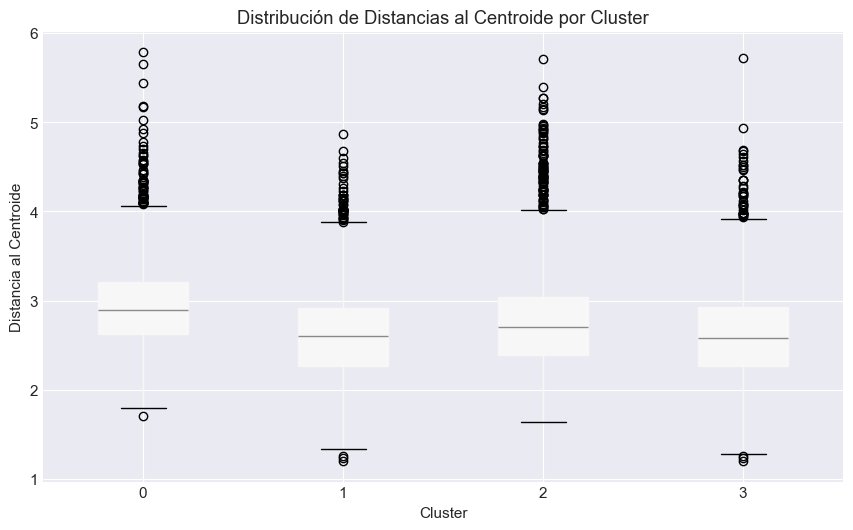

In [21]:
# Crear features derivadas del clustering
df_features = df_clean.copy()

# 1. Cluster ID como feature categórica
df_features['Cluster_ID'] = df_features['Cluster_KMeans']

# 2. Tasa de churn del cluster
cluster_churn_rate = df_features.groupby('Cluster_KMeans')['Exited'].transform('mean')
df_features['Cluster_Churn_Rate'] = cluster_churn_rate

# 3. Distancia al centroide del cluster
distances_to_centroids = []
for idx, row in df_features.iterrows():
    cluster_id = int(row['Cluster_KMeans'])
    point = X_scaled[idx]
    centroid = kmeans_final.cluster_centers_[cluster_id]
    distance = np.linalg.norm(point - centroid)
    distances_to_centroids.append(distance)

df_features['Distance_To_Centroid'] = distances_to_centroids

# 4. Indicador de cluster de alto riesgo
df_features['High_Risk_Cluster'] = df_features['Cluster_KMeans'].isin(high_risk_clusters).astype(int)

# 5. Ranking dentro del cluster por balance
df_features['Balance_Rank_In_Cluster'] = df_features.groupby('Cluster_KMeans')['Balance'].rank(pct=True)

print("✅ Features derivadas creadas:")
print(df_features[['Cluster_ID', 'Cluster_Churn_Rate', 'Distance_To_Centroid', 
                    'High_Risk_Cluster', 'Balance_Rank_In_Cluster']].head(10))

# Estadísticas de nuevas features
print("\n📊 Estadísticas de Features Derivadas:")
print(df_features[['Cluster_Churn_Rate', 'Distance_To_Centroid', 
                    'Balance_Rank_In_Cluster']].describe().round(3))

# Visualizar distancia al centroide por cluster
plt.figure(figsize=(12, 6))
df_features.boxplot(column='Distance_To_Centroid', by='Cluster_KMeans', 
                    figsize=(10, 6), patch_artist=True)
plt.xlabel('Cluster')
plt.ylabel('Distancia al Centroide')
plt.title('Distribución de Distancias al Centroide por Cluster')
plt.suptitle('')
plt.show()

## 8️⃣ Conclusiones y Recomendaciones

### 📊 Resumen de Hallazgos

#### Clustering:

**K-Means:**
- Identificó 4 segmentos principales de clientes
- Coeficiente de Silueta óptimo para K=4
- Clusters bien definidos con características distintivas
- Algunos clusters muestran tasas de churn significativamente más altas

**DBSCAN:**
- Detectó outliers en los datos (puntos atípicos)
- Útil para identificar clientes con comportamiento inusual
- Complementa el análisis de K-Means
- Los outliers pueden ser clientes de alto valor o alto riesgo

#### Reducción de Dimensionalidad:

**PCA:**
- Las primeras 3 componentes capturan ~60% de la varianza
- Visualización 2D y 3D revela estructura de clusters
- Útil para compresión de datos y eliminación de ruido
- Preserva relaciones lineales entre variables

**t-SNE:**
- Visualización no lineal revela estructura más compleja
- Perplexity=30 proporciona mejor separación visual
- Clusters son visualmente más distinguibles que en PCA
- Útil para presentaciones y exploración visual

### 🎯 Insights de Negocio:

1. **Segmentación clara**: Existen grupos de clientes con comportamientos distintivos
2. **Clusters de alto riesgo**: Algunos segmentos tienen tasas de churn >25%
3. **Patrones ocultos**: Reducción dimensional revela estructura no evidente
4. **Features útiles**: Las características de cluster pueden mejorar modelos supervisados

### 💡 Recomendaciones:

1. **Estrategias de retención personalizadas** para cada cluster
2. **Monitoreo especial** de clusters de alto riesgo
3. **Investigación adicional** de outliers detectados por DBSCAN
4. **Incorporar features de clustering** en modelos predictivos supervisados
5. **Campañas segmentadas** basadas en perfiles de cluster

### 🔄 Próximos Pasos:

1. Integrar features de clustering en modelos de avances anteriores
2. Realizar análisis temporal de migración entre clusters
3. Desarrollar estrategias específicas de retención por segmento
4. Evaluar impacto de clustering en mejora de modelos predictivos